# 06 - Model Evaluation

This notebook evaluates the selected machine learning model for student dropout prediction.

The evaluation focuses on:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- ROC-AUC score
- ROC curve

The final model will be selected based on its overall performance, with particular attention to recall and F1-score for the dropout class.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

## Load Engineered Dataset

In [2]:
df = pd.read_csv("../data/processed/student_dropout_engineered.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 24)


,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,...,Semester,Department,Parental_Education,Dropout,Academic_Performance_Score,Study_Attendance_Score,Stress_Level,Log_Family_Income,Travel_Study_Ratio,Assignment_Delay_Level
0,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,...,Year 1,Arts,High School,0,0.920000,2.89296,Medium,10.126671,0.101190,Moderate
1,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,...,Year 3,Engineering,Bachelor,1,1.223333,2.92400,Medium,10.126671,0.170543,Moderate
2,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,...,Year 1,Arts,Master,0,1.440000,3.11960,Medium,10.601224,0.185227,Low
3,24.4,Male,29740.5,Yes,4.00,82.2,2,38.6,No,No,...,Year 1,CS,High School,1,1.773333,3.28800,Medium,10.300299,0.160833,Moderate
4,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,...,Year 4,Business,Bachelor,0,1.086667,3.17183,Medium,10.139350,0.091488,Low


## Prepare Data

In [3]:
X = df.drop(columns=["Dropout"])
y = df["Dropout"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (8000, 23)
Testing set: (2000, 23)


## Create Final Logistic Regression Pipeline

In [5]:
categorical_columns = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_columns = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_columns
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_columns
        )
    ]
)

In [6]:
final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

final_model.fit(X_train, y_train)

print("Final Logistic Regression model trained successfully.")

Final Logistic Regression model trained successfully.


## Predictions

In [7]:
y_pred = final_model.predict(X_test)

print(final_model.classes_)

dropout_index = list(final_model.classes_).index(1)

y_proba = final_model.predict_proba(X_test)[:, dropout_index]

[0 1]


## Classification Report

In [8]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1529
           1       0.48      0.77      0.59       471

    accuracy                           0.75      2000
   macro avg       0.69      0.75      0.70      2000
weighted avg       0.81      0.75      0.76      2000



## Confusion Matrix

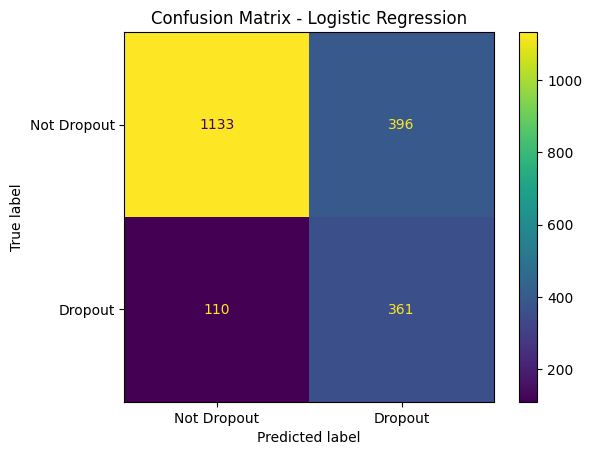

In [9]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Dropout", "Dropout"]
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## ROC-AUC

In [10]:
roc_auc = roc_auc_score(
    (y_test == 1).astype(int),
    y_proba
)

print("ROC-AUC Score:", round(roc_auc, 4))

ROC-AUC Score: 0.82


## ROC Curve

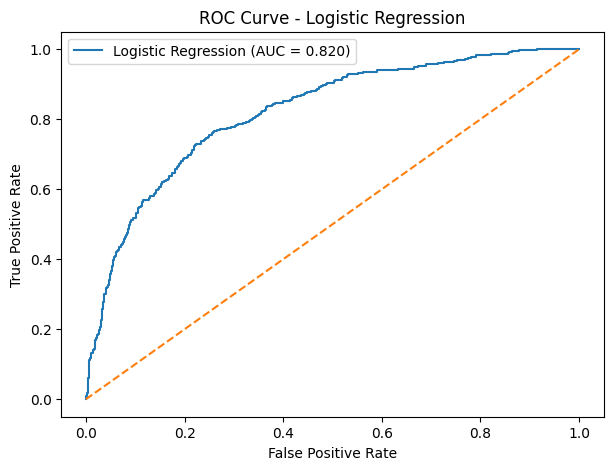

In [11]:
y_test_binary = (
    y_test == 1
).astype(int)

fpr, tpr, thresholds = roc_curve(
    y_test_binary,
    y_proba
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

## Performance Summary

In [12]:
performance = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy_score(y_test, y_pred),
        precision_score(
            y_test,
            y_pred,
            pos_label=1
        ),
        recall_score(
            y_test,
            y_pred,
            pos_label=1
        ),
        f1_score(
            y_test,
            y_pred,
            pos_label=1
        ),
        roc_auc
    ]
})

performance

,Metric,Score
0,Accuracy,0.747000
1,Precision,0.476882
2,Recall,0.766454
3,F1-Score,0.587948
4,ROC-AUC,0.820029


## Model Evaluation Summary

The Logistic Regression model achieved an accuracy of **74.70%** on the test dataset.

For the `Dropout` class, the model achieved a precision of **47.69%**, a recall of **76.65%**, and an F1-score of **58.79%**.

The relatively high recall indicates that the model is able to identify a large proportion of students who are likely to drop out. However, the lower precision indicates that some students predicted as dropouts are actually non-dropout students.

The model achieved a **ROC-AUC score of 82.00%**, indicating a good ability to distinguish between dropout and non-dropout students across different classification thresholds.

Overall, Logistic Regression provides a reasonable model for the student dropout prediction problem, particularly in identifying students who are at risk of dropping out.

## Save Final Model

In [13]:
os.makedirs("../models", exist_ok=True)

joblib.dump(
    final_model,
    "../models/student_dropout_model.pkl"
)

print("Final model saved successfully.")

Final model saved successfully.
